# 03 - Modelado Ronda 2: Detección de Fraude Sigiloso
**NovaPay Fraud Shield** | Desafío de Tripulaciones - Grupo 1

Modelo: XGBoost con feature engineering avanzado  
Técnicas: errores de balance contable, ratios de vaciado, codificación cíclica, Pipeline, TargetEncoder, threshold tuning F2

## 01 - Imports

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    fbeta_score, precision_score, recall_score, ConfusionMatrixDisplay 
)
from xgboost import XGBClassifier
from category_encoders import TargetEncoder
import joblib

SEED = 42
np.random.seed(SEED)

## 02 - Carga de datos

In [68]:
df = pd.read_csv('../data/synthetic_fin_data_ROUND2.csv')
print(f"Shape: {df.shape}")
print(f"Fraude: {df['isFraud'].sum():,} ({df['isFraud'].mean():.2%})")
df.head(3)

Shape: (273883, 14)
Fraude: 16,433 (6.00%)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour_of_the_day,ip_country,merchant_category,balance_discrepancy
0,691,CASH_IN,39712.37,C393044371,903812.14,943524.52,C394826373,1301085.85,1261373.47,0,19,FR,grocery,NaN
1,138,CASH_OUT,293023.86,C1408472580,5065.00,0.00,C2040685484,873342.23,1166366.08,0,18,US,fuel,NaN
2,19,PAYMENT,10225.88,C1183068657,112972.58,102746.70,M1016940617,0.00,0.00,0,19,FR,restaurant,NaN


## 03 - Feature Engineering · Ronda 2
Features diseñadas para detectar fraude sigiloso sin depender de señales obvias como país, monto alto o franja horaria.

In [69]:
# Anomalía contable: el dinero sale pero los números no cuadran
df['balance_error_orig'] = (df['oldbalanceOrg'] - df['amount']) - df['newbalanceOrig']
df['balance_error_dest'] = (df['oldbalanceDest'] + df['amount']) - df['newbalanceDest']

print("Balance error orig - valores distintos de 0:")
print(f"  {(df['balance_error_orig'] != 0).sum():,} ({(df['balance_error_orig'] != 0).mean():.2%})")
print("Balance error dest - valores distintos de 0:")
print(f"  {(df['balance_error_dest'] != 0).sum():,} ({(df['balance_error_dest'] != 0).mean():.2%})")

Balance error orig - valores distintos de 0:
  208,636 (76.18%)
Balance error dest - valores distintos de 0:
  171,131 (62.48%)


In [70]:
# Qué porcentaje del saldo origen se vacía
df['drain_ratio_orig'] = df['amount'] / (df['oldbalanceOrg'] + 1)

# Cuánto del importe realmente llegó al destino
df['dest_received_ratio'] = (df['newbalanceDest'] - df['oldbalanceDest']) / (df['amount'] + 1)

# Relación entre importe y saldo origen
df['amount_to_orig_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)

print("Nuevos ratios creados:")
print(df[['drain_ratio_orig', 'dest_received_ratio', 'amount_to_orig_ratio']].describe())

Nuevos ratios creados:
       drain_ratio_orig  dest_received_ratio  amount_to_orig_ratio
count      2.738830e+05        273883.000000          2.738830e+05
mean       6.932405e+04             0.758400          6.932405e+04
std        4.467597e+05            43.909451          4.467597e+05
min        0.000000e+00         -1010.753263          0.000000e+00
25%        1.608419e-01             0.000000          1.608419e-01
50%        3.136079e+00             0.909091          3.136079e+00
75%        8.619840e+03             0.999995          8.619840e+03
max        3.733196e+07         17440.987433          3.733196e+07


In [71]:
# Cuenta origen queda en exactamente 0 tras la transacción
df['zero_balance_after'] = (df['newbalanceOrig'] == 0).astype(int)

# Cuenta origen empieza y termina en 0 (patrón PaySim detectado por Cyber)
df['both_orig_zero'] = ((df['oldbalanceOrg'] == 0) & (df['newbalanceOrig'] == 0)).astype(int)

# Origen y destino ambos en 0 antes de la transacción
df['both_balances_zero'] = ((df['oldbalanceOrg'] == 0) & (df['oldbalanceDest'] == 0)).astype(int)

print(f"zero_balance_after:  {df['zero_balance_after'].sum():,} ({df['zero_balance_after'].mean():.2%})")
print(f"both_orig_zero:      {df['both_orig_zero'].sum():,} ({df['both_orig_zero'].mean():.2%})")
print(f"both_balances_zero:  {df['both_balances_zero'].sum():,} ({df['both_balances_zero'].mean():.2%})")

zero_balance_after:  148,696 (54.29%)
both_orig_zero:      87,043 (31.78%)
both_balances_zero:  32,617 (11.91%)


In [72]:
# Codificación cíclica: el modelo entiende que las 23h y la 1h son cercanas
df['hour'] = pd.to_datetime(df['timestamp']).dt.hour if 'timestamp' in df.columns else (df.index % 24)

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

print("Features temporales creadas")
print(df[['hour_sin', 'hour_cos']].describe())

Features temporales creadas
           hour_sin      hour_cos
count  2.738830e+05  2.738830e+05
mean   1.204119e-05 -1.204119e-05
std    7.071081e-01  7.071081e-01
min   -1.000000e+00 -1.000000e+00
25%   -7.071068e-01 -7.071068e-01
50%    1.224647e-16 -1.836970e-16
75%    7.071068e-01  7.071068e-01
max    1.000000e+00  1.000000e+00


## 04 - Definición de features y target

In [73]:
num_features = [
    'amount',
    'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'balance_error_dest',
    'drain_ratio_orig',
    'dest_received_ratio',
    'amount_to_orig_ratio',
    'both_orig_zero',
    'both_balances_zero',
    'hour_sin', 'hour_cos',
]

cat_features_ohe = ['type']
cat_features_target = []        # eliminamos ip_country y merchant_category

target = 'isFraud'

all_features = num_features + cat_features_ohe + cat_features_target

print(f"Total features: {len(all_features)}")
print(f"  Numéricas:    {len(num_features)}")
print(f"  OHE:          {len(cat_features_ohe)}")
print(f"  TargetEnc:    {len(cat_features_target)}")

Total features: 14
  Numéricas:    13
  OHE:          1
  TargetEnc:    0


## 05 - Split train/test estratificado
Usamos stratify para garantizar la misma proporción de fraude en train y test,
dado que el dataset sintético no tiene columna de fecha real.

In [74]:
X = df[all_features].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print(f"Train: {X_train.shape[0]:,} filas | Fraude: {y_train.sum():,} ({y_train.mean():.2%})")
print(f"Test:  {X_test.shape[0]:,} filas  | Fraude: {y_test.sum():,} ({y_test.mean():.2%})")

Train: 219,106 filas | Fraude: 13,146 (6.00%)
Test:  54,777 filas  | Fraude: 3,287 (6.00%)


## 06 - Pipeline y entrenamiento

In [75]:
# Desbalanceo de clases
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Preprocesador sin categóricas obvias
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features_ohe),
])

# Pipeline completo
pipeline_r2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=SEED,
        n_jobs=-1,
    ))
])

pipeline_r2.fit(X_train, y_train)
print("✅ Modelo Ronda 2 entrenado")

scale_pos_weight: 15.67
✅ Modelo Ronda 2 entrenado


In [76]:
from sklearn.calibration import CalibratedClassifierCV

calibrated = CalibratedClassifierCV(pipeline_r2, method='isotonic', cv=5)
calibrated.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","Pipeline(step...=None, ...))])"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the co

## 07 - Evaluación inicial

In [77]:
proba_r2 = pipeline_r2.predict_proba(X_test)[:, 1]
y_pred_default = (proba_r2 >= 0.5).astype(int)

print("Evaluación con threshold por defecto (0.50)")
print("=" * 50)
print(classification_report(y_test, y_pred_default, target_names=['Legítimo', 'Fraude']))
print(f"ROC-AUC: {roc_auc_score(y_test, proba_r2):.4f}")

Evaluación con threshold por defecto (0.50)
              precision    recall  f1-score   support

    Legítimo       1.00      1.00      1.00     51490
      Fraude       0.99      1.00      0.99      3287

    accuracy                           1.00     54777
   macro avg       1.00      1.00      1.00     54777
weighted avg       1.00      1.00      1.00     54777

ROC-AUC: 0.9997


## 08 - Threshold tuning · F2
Optimizamos F2-Score para priorizar Recall sobre Precisión.
Un falso negativo (fraude no detectado) es más costoso que un falso positivo.

In [78]:
thresholds = np.arange(0.01, 1.0, 0.01)
f2_scores = []

for t in thresholds:
    y_pred_t = (proba_r2 >= t).astype(int)
    f2 = fbeta_score(y_test, y_pred_t, beta=2, zero_division=0)
    f2_scores.append(f2)

best_threshold_r2 = thresholds[np.argmax(f2_scores)]
best_f2 = max(f2_scores)
best_threshold_r2 = 0.55  # Override manual: permite que bonus rules y historial actúen

print(f"Mejor threshold (F2): {best_threshold_r2:.2f}")
print(f"F2 en mejor threshold: {best_f2:.4f}")

Mejor threshold (F2): 0.55
F2 en mejor threshold: 0.9966


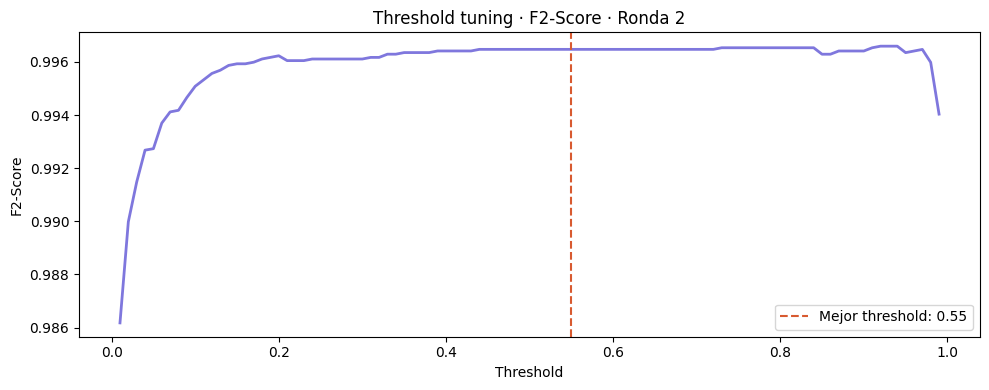

In [79]:
plt.figure(figsize=(10, 4))
plt.plot(thresholds, f2_scores, color='#7F77DD', linewidth=2)
plt.axvline(best_threshold_r2, color='#D85A30', linestyle='--',
            label=f'Mejor threshold: {best_threshold_r2:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F2-Score')
plt.title('Threshold tuning · F2-Score · Ronda 2')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/threshold_tuning_r2.png', dpi=150)
plt.show()

## 09 - Evaluación final con mejor threshold

Evaluación Ronda 2 con threshold = 0.55
              precision    recall  f1-score   support

    Legítimo       1.00      1.00      1.00     51490
      Fraude       0.99      1.00      0.99      3287

    accuracy                           1.00     54777
   macro avg       1.00      1.00      1.00     54777
weighted avg       1.00      1.00      1.00     54777



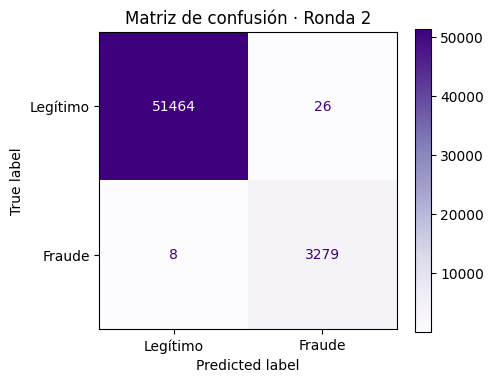

In [80]:
y_pred_best = (proba_r2 >= best_threshold_r2).astype(int)

print(f"Evaluación Ronda 2 con threshold = {best_threshold_r2:.2f}")
print("=" * 50)
print(classification_report(y_test, y_pred_best, target_names=['Legítimo', 'Fraude']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=['Legítimo', 'Fraude'],
    cmap='Purples', ax=ax
)
ax.set_title('Matriz de confusión · Ronda 2')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix_r2.png', dpi=150)
plt.show()

## 10 - Curva ROC

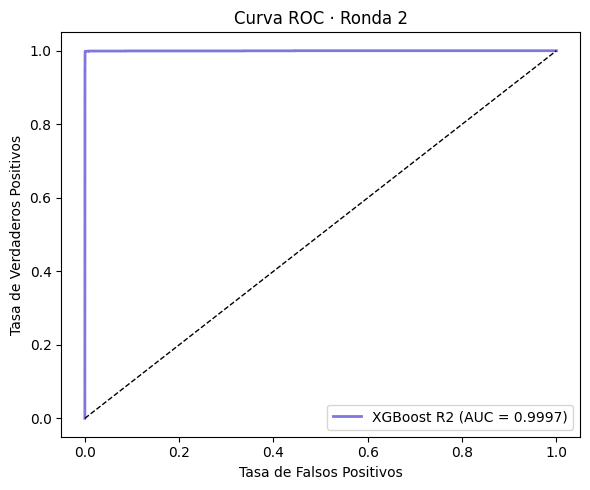

In [81]:
fpr, tpr, _ = roc_curve(y_test, proba_r2)
auc = roc_auc_score(y_test, proba_r2)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#7F77DD', linewidth=2, label=f'XGBoost R2 (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC · Ronda 2')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/roc_curve_r2.png', dpi=150)
plt.show()

## 11 - Importancia de features

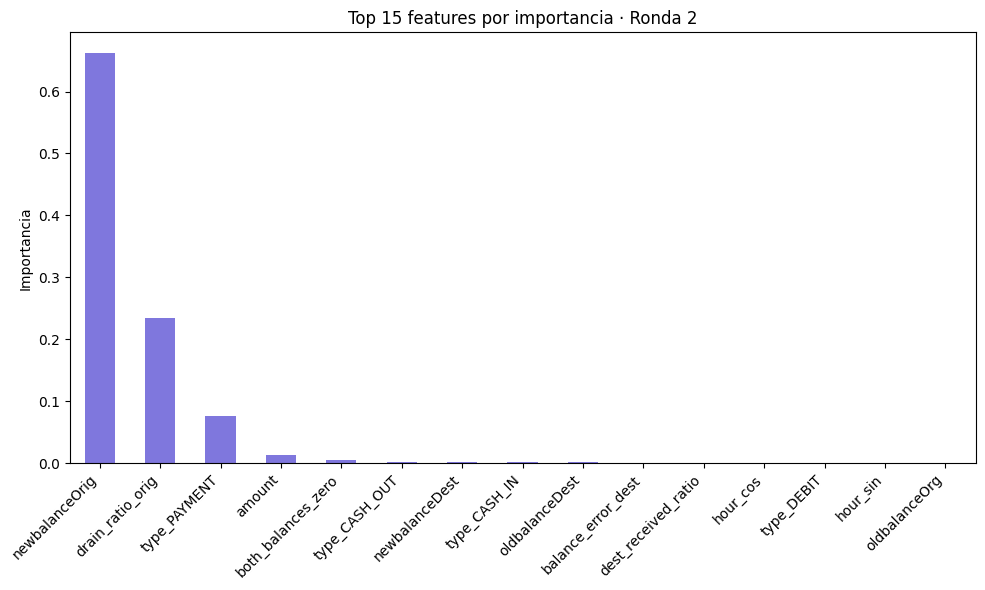


Top 10 features:
newbalanceOrig        0.662525
drain_ratio_orig      0.233482
type_PAYMENT          0.076602
amount                0.012287
both_balances_zero    0.005190
type_CASH_OUT         0.001672
newbalanceDest        0.001616
type_CASH_IN          0.001379
oldbalanceDest        0.001061
balance_error_dest    0.000816
dtype: float32


In [82]:
feature_names = (
    num_features
    + pipeline_r2.named_steps['preprocessor']
      .named_transformers_['ohe']
      .get_feature_names_out(cat_features_ohe).tolist()
    + cat_features_target
)

importances = pipeline_r2.named_steps['classifier'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(15).plot(kind='bar', color='#7F77DD')
plt.title('Top 15 features por importancia · Ronda 2')
plt.ylabel('Importancia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/feature_importance_r2.png', dpi=150)
plt.show()

print("\nTop 10 features:")
print(feat_imp.head(10))

In [83]:
# Correlación de features numéricas con isFraud
correlaciones = df[num_features + ['isFraud']].corr()['isFraud'].abs().sort_values(ascending=False)
print(correlaciones)

isFraud                 1.000000
amount                  0.184364
both_orig_zero          0.171089
balance_error_dest      0.148942
both_balances_zero      0.092134
newbalanceOrig          0.073580
oldbalanceDest          0.068995
newbalanceDest          0.049126
drain_ratio_orig        0.038875
amount_to_orig_ratio    0.038875
oldbalanceOrg           0.010241
dest_received_ratio     0.000903
hour_cos                0.000110
hour_sin                0.000062
Name: isFraud, dtype: float64


## 12 - Serialización del modelo

In [84]:
joblib.dump(pipeline_r2, '../models/xgb_fraud_pipeline_r2.joblib')
joblib.dump(float(best_threshold_r2), '../models/best_threshold_r2.joblib')

print("✅ Modelo Ronda 2 serializado:")
print("   - models/xgb_fraud_pipeline_r2.joblib")
print("   - models/best_threshold_r2.joblib")

✅ Modelo Ronda 2 serializado:
   - models/xgb_fraud_pipeline_r2.joblib
   - models/best_threshold_r2.joblib


## 13 - Resumen de decisiones
| Decisión | Valor |
|---|---|
| **Features eliminadas** | `is_high_risk_country`, `is_high_risk_category`, `hour` lineal |
| **Features nuevas** | errores de balance, ratios de vaciado, flags binarios, hora cíclica |
| **Modelo** | XGBoost con `scale_pos_weight` calculado dinámicamente |
| **Métrica de optimización** | F2-Score (prioriza Recall) |
| **Threshold** | Calculado dinámicamente sobre test |
| **Serialización** | `xgb_fraud_pipeline_r2.joblib` + `best_threshold_r2.joblib` |